In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## 1. Lineare kleinste Quadrate

Hier definiere ich eine Funktion, die das lineare kleinste-Quadrate-Problem fuer ein Modell der Form

f(x)=ax+b

loest. Dafuer wird die Matrix \(A\) aufgebaut und danach `np.linalg.lstsq` benutzt.

In [2]:
def linear_least_squares(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)

    A = np.column_stack((x, np.ones(len(x))))
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]

    return a, b

## Linearisierung des exponentiellen Modells

Da die Daten ungefaehr exponentiell wachsen, verwende ich die Transformation

\tilde y = ln(y)

Dadurch wird aus dem exponentiellen Modell ein lineares Modell:

ln(y)=ax+b

Danach kann ich wieder lineare kleinste Quadrate anwenden.

In [3]:
# Original data
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18], dtype=float)
y = np.array([1, 1, 3, 3, 3, 3, 4, 6, 6, 9, 13, 15, 17, 29, 47, 59, 89, 123], dtype=float)

# Linearization
y_log = np.log(y)

# Linear least squares on (x, ln(y))
a, b = linear_least_squares(x, y_log)

print("Original complete data:")
print(f"a = {a:.6f}")
print(f"b = {b:.6f}")
print(f"Linearized model: ln(y) = {a:.6f}x + {b:.6f}")
print(f"Exponential model: y = exp({a:.6f}x + {b:.6f})")

Original complete data:
a = 0.268342
b = -0.312391
Linearized model: ln(y) = 0.268342x + -0.312391
Exponential model: y = exp(0.268342x + -0.312391)


## Extrapolation fuer x=30

Mit dem gefundenen Modell berechne ich nun den vorhergesagten Wert fuer Tag 30. Danach vergleiche ich diesen Wert mit dem echten Wert 1029.

In [4]:
# Prediction for day 30
x_pred = 30
actual_value = 1029

prediction = np.exp(a * x_pred + b)

absolute_error = abs(prediction - actual_value)
relative_error = absolute_error / actual_value * 100

print(f"Prediction for x = 30: {prediction:.2f}")
print(f"Actual value: {actual_value}")
print(f"Absolute error: {absolute_error:.2f}")
print(f"Relative error: {relative_error:.2f}%")

Prediction for x = 30: 2293.60
Actual value: 1029
Absolute error: 1264.60
Relative error: 122.90%


## Fall mit fehlenden Daten

Jetzt wiederhole ich die gleiche Rechnung mit dem kleineren Datensatz. Danach kann ich vergleichen, wie stark sich die Parameter und die Vorhersage aendern.

In [5]:
# Missing data
x_missing = np.array([1, 4, 7, 10, 13, 16], dtype=float)
y_missing = np.array([1, 3, 4, 9, 17, 59], dtype=float)

y_missing_log = np.log(y_missing)

a_missing, b_missing = linear_least_squares(x_missing, y_missing_log)

print("Data with missing values:")
print(f"a_missing = {a_missing:.6f}")
print(f"b_missing = {b_missing:.6f}")
print(f"Linearized model: ln(y) = {a_missing:.6f}x + {b_missing:.6f}")
print(f"Exponential model: y = exp({a_missing:.6f}x + {b_missing:.6f})")

Data with missing values:
a_missing = 0.251452
b_missing = -0.205192
Linearized model: ln(y) = 0.251452x + -0.205192
Exponential model: y = exp(0.251452x + -0.205192)


In [6]:
# Prediction with missing data model
prediction_missing = np.exp(a_missing * x_pred + b_missing)

absolute_error_missing = abs(prediction_missing - actual_value)
relative_error_missing = absolute_error_missing / actual_value * 100

print(f"Prediction for x = 30 with missing data: {prediction_missing:.2f}")
print(f"Actual value: {actual_value}")
print(f"Absolute error: {absolute_error_missing:.2f}")
print(f"Relative error: {relative_error_missing:.2f}%")

Prediction for x = 30 with missing data: 1538.18
Actual value: 1029
Absolute error: 509.18
Relative error: 49.48%


In [7]:
# Parameter differences
diff_a = abs(a - a_missing)
diff_b = abs(b - b_missing)

print("Differences between parameters:")
print(f"|a - a_missing| = {diff_a:.6f}")
print(f"|b - b_missing| = {diff_b:.6f}")

Differences between parameters:
|a - a_missing| = 0.016891
|b - b_missing| = 0.107200


## Darstellung der linearisierten Daten

Hier werden die Daten (x, ln(y)) zusammen mit den beiden Regressionsgeraden dargestellt: einmal fuer alle Daten und einmal fuer den Datensatz mit fehlenden Werten.

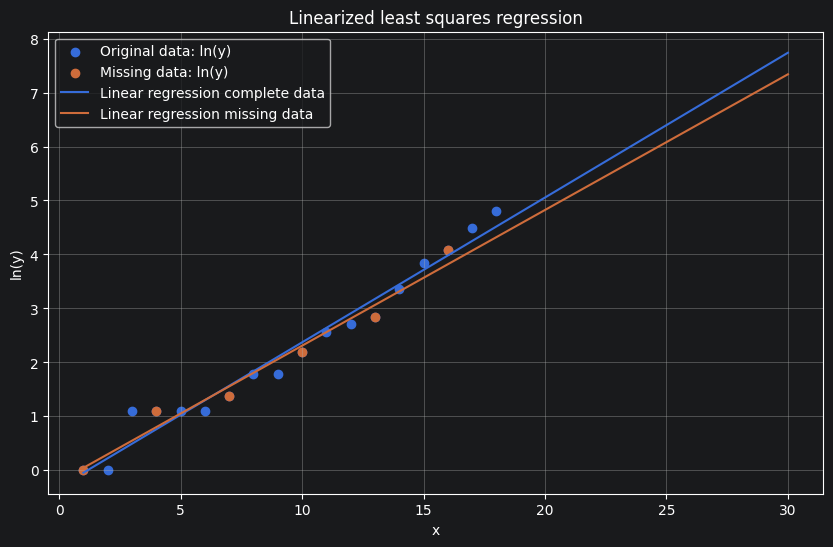

In [8]:
# Plot linearized data and regression lines

x_plot = np.linspace(1, 30, 300)

y_log_fit = a * x_plot + b
y_log_fit_missing = a_missing * x_plot + b_missing

plt.figure(figsize=(10, 6))

plt.scatter(x, y_log, label="Original data: ln(y)")
plt.scatter(x_missing, y_missing_log, label="Missing data: ln(y)")

plt.plot(x_plot, y_log_fit, label="Linear regression complete data")
plt.plot(x_plot, y_log_fit_missing, label="Linear regression missing data")

plt.xlabel("x")
plt.ylabel("ln(y)")
plt.title("Linearized least squares regression")
plt.legend()
plt.grid(True)
plt.show()

## Darstellung der exponentiellen Modelle

Hier werden die urspruenglichen Daten (x,y) und die dazugehoerigen exponentiellen Regressionskurven dargestellt. Zusaetzlich wird der echte Wert fuer x=30 markiert.

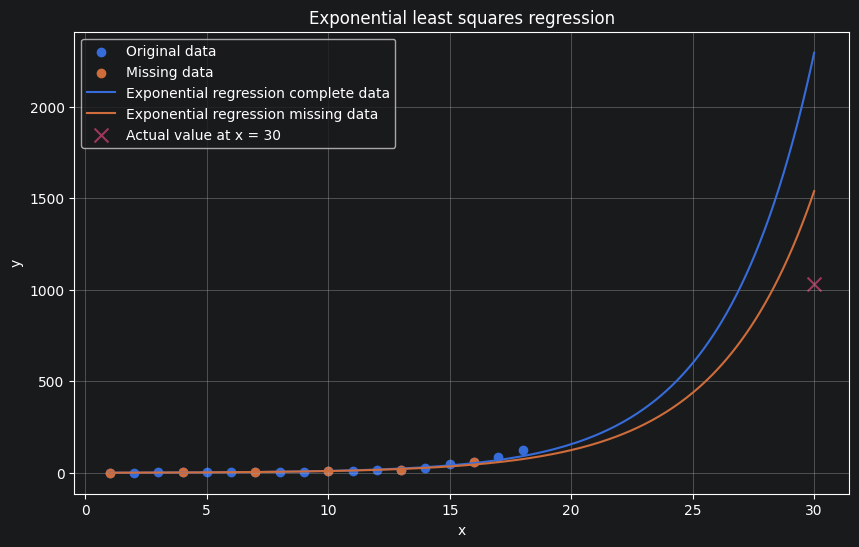

In [9]:
# Plot original data and exponential regression curves

y_exp_fit = np.exp(a * x_plot + b)
y_exp_fit_missing = np.exp(a_missing * x_plot + b_missing)

plt.figure(figsize=(10, 6))

plt.scatter(x, y, label="Original data")
plt.scatter(x_missing, y_missing, label="Missing data")

plt.plot(x_plot, y_exp_fit, label="Exponential regression complete data")
plt.plot(x_plot, y_exp_fit_missing, label="Exponential regression missing data")

plt.scatter([30], [actual_value], marker="x", s=100, label="Actual value at x = 30")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Exponential least squares regression")
plt.legend()
plt.grid(True)
plt.show()

## Ergebnis zu Aufgabe 1

Das Modell mit allen Daten ueberschaetzt den Wert fuer Tag 30 deutlich. Das Modell mit fehlenden Daten ueberschaetzt den Wert auch, ist aber naeher am echten Wert.

Man sieht also, dass Extrapolation außerhalb des gemessenen Bereichs ziemlich ungenau sein kann.

In [10]:
print("Final comparison:")

print(f"Complete data model:")
print(f"y = exp({a:.6f}x + {b:.6f})")
print(f"Prediction at x = 30: {prediction:.2f}")
print(f"Relative error: {relative_error:.2f}%")

print()

print(f"Missing data model:")
print(f"y = exp({a_missing:.6f}x + {b_missing:.6f})")
print(f"Prediction at x = 30: {prediction_missing:.2f}")
print(f"Relative error: {relative_error_missing:.2f}%")

Final comparison:
Complete data model:
y = exp(0.268342x + -0.312391)
Prediction at x = 30: 2293.60
Relative error: 122.90%

Missing data model:
y = exp(0.251452x + -0.205192)
Prediction at x = 30: 1538.18
Relative error: 49.48%


# 2. Nichtlineare kleinste Quadrate

In dieser Aufgabe wird das Weibull-Modell

W(x,a,b)=abx^{b-1}e^{-ax^b}

an die gegebenen Daten angepasst. Dieses Modell ist echt nichtlinear, deshalb benutze ich `curve_fit` mit `method="lm"`, also den Levenberg-Marquardt-Algorithmus.

In [11]:
x_weibull = np.array([0.132, 0.511, 0.701, 0.891, 1.081, 1.27, 1.46, 1.65, 1.839, 2.029, 2.219])
y_weibull = np.array([0.1, 0.543, 0.506, 0.606, 0.622, 0.569, 0.453, 0.438, 0.316, 0.29, 0.195])

In [12]:
# Weibull model
# W(x, a, b) = a*b*x^(b-1)*exp(-a*x^b)

def weibull_model(x, a, b):
    return a * b * x**(b - 1) * np.exp(-a * x**b)

## Anpassung des vollen Weibull-Modells

Hier werden die optimalen Parameter a und b fuer das volle Weibull-Modell bestimmt.

In [13]:
# Levenberg-Marquardt fit
# method="lm" uses Levenberg-Marquardt

initial_guess = [1, 2]

params, covariance = curve_fit(
    weibull_model,
    x_weibull,
    y_weibull,
    p0=initial_guess,
    method="lm",
    maxfev=10000
)

a_weibull, b_weibull = params

print("Full Weibull model:")
print(f"a = {a_weibull:.6f}")
print(f"b = {b_weibull:.6f}")

y_fit_weibull = weibull_model(x_weibull, a_weibull, b_weibull)

sse_full = np.sum((y_weibull - y_fit_weibull)**2)
rmse_full = np.sqrt(np.mean((y_weibull - y_fit_weibull)**2))

print(f"SSE = {sse_full:.6f}")
print(f"RMSE = {rmse_full:.6f}")

Full Weibull model:
a = 0.517088
b = 1.965840
SSE = 0.015491
RMSE = 0.037527


## Reduziertes Modell

Da der berechnete Wert von b sehr nahe bei 2 liegt, vergleiche ich das volle Modell mit dem reduzierten Modell

W_r(x,a)=2axe^{-ax^2}

In [14]:
# Reduced model
# Wr(x, a) = 2*a*x*exp(-a*x^2)

def reduced_model(x, a):
    return 2 * a * x * np.exp(-a * x**2)

In [15]:
params_reduced, covariance_reduced = curve_fit(
    reduced_model,
    x_weibull,
    y_weibull,
    p0=[1],
    method="lm",
    maxfev=10000
)

a_reduced = params_reduced[0]

print("Reduced model:")
print(f"a_reduced = {a_reduced:.6f}")

y_fit_reduced = reduced_model(x_weibull, a_reduced)

sse_reduced = np.sum((y_weibull - y_fit_reduced)**2)
rmse_reduced = np.sqrt(np.mean((y_weibull - y_fit_reduced)**2))

print(f"SSE = {sse_reduced:.6f}")
print(f"RMSE = {rmse_reduced:.6f}")

Reduced model:
a_reduced = 0.511722
SSE = 0.015935
RMSE = 0.038061


## Vergleich der Regressionskurven

In der Grafik werden die Messdaten, das volle Weibull-Modell und das reduzierte Modell zusammen dargestellt.

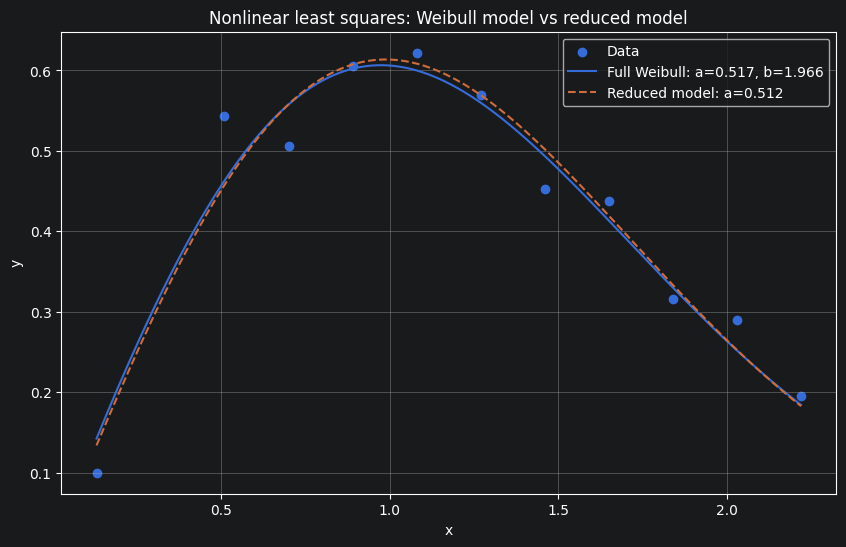

In [16]:
x_plot_weibull = np.linspace(min(x_weibull), max(x_weibull), 500)

y_plot_full = weibull_model(x_plot_weibull, a_weibull, b_weibull)
y_plot_reduced = reduced_model(x_plot_weibull, a_reduced)

plt.figure(figsize=(10, 6))

plt.scatter(x_weibull, y_weibull, label="Data")
plt.plot(x_plot_weibull, y_plot_full, label=f"Full Weibull: a={a_weibull:.3f}, b={b_weibull:.3f}")
plt.plot(x_plot_weibull, y_plot_reduced, "--", label=f"Reduced model: a={a_reduced:.3f}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Nonlinear least squares: Weibull model vs reduced model")
plt.legend()
plt.grid(True)
plt.show()

## Ergebnis zu Aufgabe 2

Das volle Modell hat eine etwas kleinere Fehlerquadratsumme als das reduzierte Modell. Der Unterschied ist aber sehr klein.

Deshalb ist der Parameter b fuer diese Daten nicht besonders wesentlich. Das reduzierte Modell mit b=2 passt fast genauso gut.

In [17]:
print("Comparison:")
print(f"Full model SSE:    {sse_full:.6f}")
print(f"Reduced model SSE: {sse_reduced:.6f}")
print(f"Difference in SSE: {sse_reduced - sse_full:.6f}")

print()
print(f"Full model:    W(x)  = {a_weibull:.6f} * {b_weibull:.6f} * x^({b_weibull:.6f}-1) * exp(-{a_weibull:.6f} * x^{b_weibull:.6f})")
print(f"Reduced model: Wr(x) = 2 * {a_reduced:.6f} * x * exp(-{a_reduced:.6f} * x^2)")

Comparison:
Full model SSE:    0.015491
Reduced model SSE: 0.015935
Difference in SSE: 0.000444

Full model:    W(x)  = 0.517088 * 1.965840 * x^(1.965840-1) * exp(-0.517088 * x^1.965840)
Reduced model: Wr(x) = 2 * 0.511722 * x * exp(-0.511722 * x^2)


## Zusammenfassung der Ergebnisse

### Aufgabe 1

Fuer das exponentielle Modell ergibt sich nach der Linearisierung
ln(y)=ax+b mit den Parametern a=0.268342,\quad b=-0.312391

Die Vorhersage fuer x=30 ist y(30)\approx 2293.60

Der reale Wert ist 1029, daher überschätzt das Modell den Wert deutlich.
Fuer den Datensatz mit fehlenden Daten erhält man a=0.251452,\quad b=-0.205192 mit der Vorhersage y(30)\approx 1538.18

Diese liegt aeher am echten Wert, ist aber immer noch zu groß. Die Parameter unterscheiden sich nur leicht vom vollstaendigen Modell.

---

### Aufgabe 2

Fuer das Weibull-Modell

W(x,a,b)=abx^{b-1}e^{-ax^b}

liefert das Levenberg-Marquardt-Verfahren a=0.517,\quad b=1.966


Das reduzierte Modell

W_r(x,a)=2axe^{-ax^2} liefert a=0.512

Die Fehlerquadratsummen sind

SSE_{voll}=0.015491,\quad
SSE_{reduziert}=0.015935

Da der Unterschied sehr klein ist und b\approx2\, ist der Parameter b nicht wesentlich. Das reduzierte Modell beschreibt die Daten fast genauso gut.